In [99]:
import numpy as np
import math
import matplotlib.pyplot as plt
from iminuit import Minuit, minimize
from scipy import integrate
#import binom
from scipy.stats import binom, norm

In [55]:
def beta(x, a, b):
    return math.gamma(a + b) / (math.gamma(a) * math.gamma(b)) * x**(a - 1) * (1 - x)**(b - 1)


array([0.00000000e+000, 7.98237222e-106, 4.15589035e-086, 1.22368641e-074,
       1.51010592e-066, 2.62308709e-060, 3.06794929e-055, 5.56803776e-051,
       2.58102304e-047, 4.21401760e-044, 3.01790544e-041, 1.10859643e-038,
       2.34456474e-036, 3.11640574e-034, 2.78701451e-032, 1.76996315e-030,
       8.33718421e-029, 3.01818039e-027, 8.64811349e-026, 2.01021552e-024,
       3.87031416e-023, 6.28254120e-022, 8.73025626e-021, 1.05231247e-019,
       1.11293630e-018, 1.04319247e-017, 8.74306308e-017, 6.60326482e-016,
       4.52542453e-015, 2.83169597e-014, 1.62673682e-013, 8.62224237e-013,
       4.23533008e-012, 1.93579446e-011, 8.26243493e-011, 3.30411720e-010,
       1.24162124e-009, 4.39619181e-009, 1.47020254e-008, 4.65427434e-008,
       1.39756889e-007, 3.98778491e-007, 1.08303791e-006, 2.80386041e-006,
       6.92872768e-006, 1.63628574e-005, 3.69693537e-005, 7.99866870e-005,
       1.65864352e-004, 3.29888238e-004, 6.29698137e-004, 1.15419475e-003,
       2.03232543e-003, 3

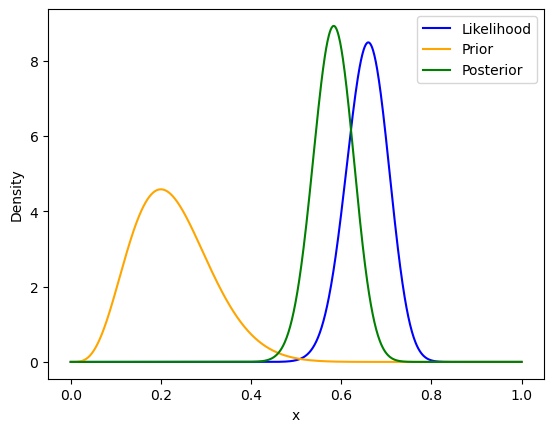

In [98]:
plt.style.use('seaborn-v0_8-colorblind')
x_values = np.linspace(0, 1, 1000)
likelihood = binom.pmf(66, 100, x_values)
likelihood_norm = likelihood / np.trapz(likelihood, x_values)
prior = beta(x_values, 5, 17)
prior_norm = prior / np.trapz(prior, x_values)
posterior = likelihood * prior
posterior_norm = posterior / np.trapz(posterior, x_values)

plt.plot(x_values, likelihood_norm, label='Likelihood', color='blue')
plt.plot(x_values, prior_norm, label='Prior', color='orange')
plt.plot(x_values, posterior_norm, label='Posterior', color='green')
plt.xlabel('x')
plt.ylabel('Density')
# plt.title('Likelihood, Prior, and Posterior Distributions')
plt.legend();

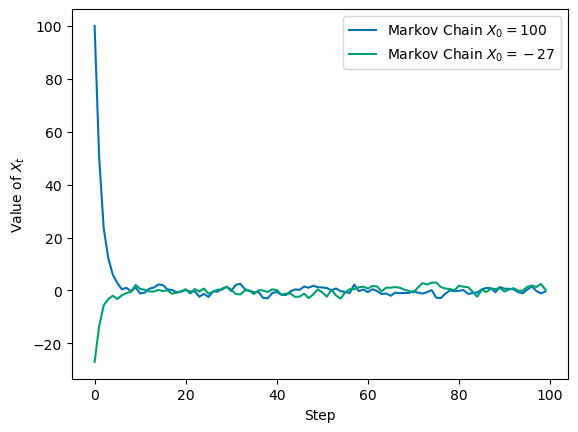

In [ ]:
step = lambda Xt: np.random.normal(loc = 0.5*Xt, scale = 1)

def markov_chain(Xt, steps):
    Xs = np.zeros(steps)
    Xs[0] = Xt
    for i in range(1, steps):
        Xs[i] = step(Xs[i-1])
    return Xs

plt.plot(markov_chain(100, 100), label='Markov Chain $X_0=100$')
plt.plot(markov_chain(-27, 100), label='Markov Chain $X_0=-27$')
plt.legend()
plt.xlabel('Step')
plt.ylabel('Value of $X_t$');

In [146]:
np.arange(10)[-8:]

array([2, 3, 4, 5, 6, 7, 8, 9])

In [164]:
convergence = np.zeros((19, 90))
# convergence
for i in range(19):
    convergence[i] = markov_chain(10*(i-9), 100)[-90:]
convergence_mean = np.mean(convergence)
convergence_std = np.std(convergence)
print(f"Mean of last 80 steps: {convergence_mean:.2f}")
print(f"Standard deviation of last 80 steps: {convergence_std:.2f}")


Mean of last 80 steps: -0.03
Standard deviation of last 80 steps: 1.15


# Exercise 3